<a href="https://colab.research.google.com/github/miriamamin1213-ux/Seed42_Models/blob/main/DT.Hancock.NoSmote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (332, 25)

Class Distribution
HPV
0    191
1    141
Name: count, dtype: int64

Training Patients: 265
Test Patients: 67

Number of Features: 25

Training samples without SMOTE:
HPV
0    152
1    113
Name: count, dtype: int64

Classification Report

              precision    recall  f1-score   support

           0     0.7692    0.7692    0.7692        39
           1     0.6786    0.6786    0.6786        28

    accuracy                         0.7313        67
   macro avg     0.7239    0.7239    0.7239        67
weighted avg     0.7313    0.7313    0.7313        67

Confusion Matrix
[[30  9]
 [ 9 19]]

Accuracy:            0.7313
Balanced Accuracy:   0.7239
F1-score:            0.6786
AUC:                 0.7239

DECISION TREE42_HANCOCK SUMMARY
Model : Decision Tree
Input Features : 25
Learning Rate : N/A
Optimiser : N/A
Class Weights : None

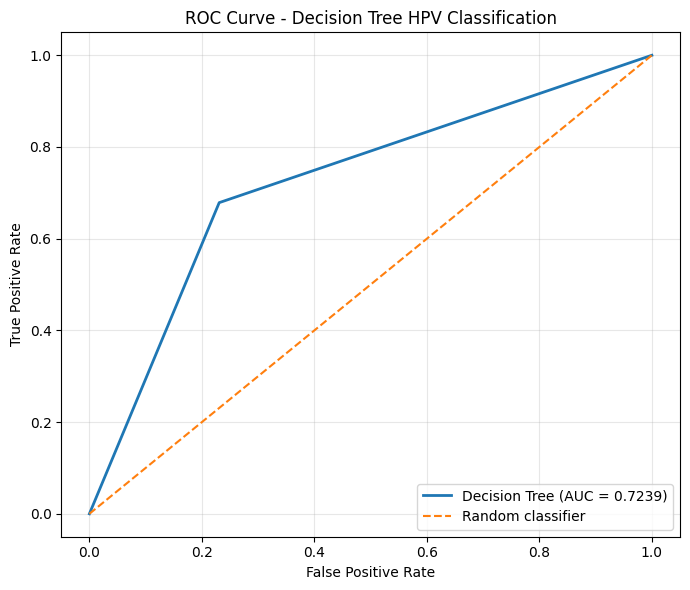

AUC: 0.7239


In [2]:
# ============================================================
# DT42_Hancock
# No SMOTE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

# ------------------------------------------------------------
# Read Data
# ------------------------------------------------------------

with open('/content/drive/MyDrive/clinical_data.json') as f:
    clinical = pd.DataFrame(json.load(f))

with open('/content/drive/MyDrive/pathological_data.json') as f:
    pathology = pd.DataFrame(json.load(f))

df = clinical.merge(
    pathology,
    on='patient_id',
    how='inner'
)

# ------------------------------------------------------------
# HPV Labels
# ------------------------------------------------------------

df = df[
    df['hpv_association_p16'].isin(
        ['positive', 'negative']
    )
].copy()

df['HPV'] = df['hpv_association_p16'].map({
    'negative': 0,
    'positive': 1
})

# ------------------------------------------------------------
# Build Modelling Dataset
# ------------------------------------------------------------

df_model = df[
[
    'age_at_initial_diagnosis',
    'sex',
    'smoking_status',
    'primarily_metastasis',
    'first_treatment_intent',
    'first_treatment_modality',
    'days_to_first_treatment',
    'adjuvant_treatment_intent',
    'adjuvant_radiotherapy',
    'adjuvant_radiotherapy_modality',
    'adjuvant_systemic_therapy',
    'adjuvant_systemic_therapy_modality',
    'adjuvant_radiochemotherapy',
    'primary_tumor_site',
    'pT_stage',
    'pN_stage',
    'histologic_type',
    'number_of_positive_lymph_nodes',
    'number_of_resected_lymph_nodes',
    'perinodal_invasion',
    'lymphovascular_invasion_L',
    'vascular_invasion_V',
    'perineural_invasion_Pn',
    'resection_status',
    'infiltration_depth_in_mm',
    'HPV'
]
].copy()

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------

cat_cols = [
    'sex',
    'smoking_status',
    'primarily_metastasis',
    'first_treatment_intent',
    'first_treatment_modality',
    'adjuvant_treatment_intent',
    'adjuvant_radiotherapy',
    'adjuvant_radiotherapy_modality',
    'adjuvant_systemic_therapy',
    'adjuvant_systemic_therapy_modality',
    'adjuvant_radiochemotherapy',
    'primary_tumor_site',
    'pT_stage',
    'pN_stage',
    'histologic_type',
    'perinodal_invasion',
    'lymphovascular_invasion_L',
    'vascular_invasion_V',
    'perineural_invasion_Pn',
    'resection_status'
]

for col in cat_cols:

    df_model[col] = df_model[col].fillna(
        df_model[col].mode()[0]
    )

num_cols = [
    'age_at_initial_diagnosis',
    'days_to_first_treatment',
    'number_of_positive_lymph_nodes',
    'number_of_resected_lymph_nodes',
    'infiltration_depth_in_mm'
]

for col in num_cols:

    df_model[col] = df_model[col].fillna(
        df_model[col].median()
    )

# ------------------------------------------------------------
# Label Encoding
# ------------------------------------------------------------

for col in cat_cols:

    df_model[col] = LabelEncoder().fit_transform(
        df_model[col].astype(str)
    )

# ------------------------------------------------------------
# Features and Target
# ------------------------------------------------------------

X = df_model.drop(columns=['HPV'])
y = df_model['HPV']

print("Dataset Shape:", X.shape)

print("\nClass Distribution")

print(y.value_counts())

# ------------------------------------------------------------
# Train/Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("\nTraining Patients:", len(y_train))
print("Test Patients:", len(y_test))

# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

n_features = X.shape[1]

print("\nNumber of Features:", n_features)

# ------------------------------------------------------------
# No SMOTE
# ------------------------------------------------------------

print("\nTraining samples without SMOTE:")

print(
    pd.Series(y_train).value_counts()
)


# ------------------------------------------------------------
# Decision Tree Model
# ------------------------------------------------------------

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=SEED
)

model.fit(
    X_train,
    y_train
)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predicted = model.predict(
    X_test
)

probabilities = model.predict_proba(
    X_test
)[:,1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print()

print("Classification Report\n")

print(
    classification_report(
        y_test,
        predicted,
        digits=4
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    predicted
)

print("Confusion Matrix")

print(cm)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = (
    (predicted == y_test).sum()
    /
    len(y_test)
)

bal_acc = balanced_accuracy_score(
    y_test,
    predicted
)

f1 = f1_score(
    y_test,
    predicted
)

auc = roc_auc_score(
    y_test,
    probabilities
)

print()

print(f"Accuracy:            {accuracy:.4f}")

print(f"Balanced Accuracy:   {bal_acc:.4f}")

print(f"F1-score:            {f1:.4f}")

print(f"AUC:                 {auc:.4f}")

# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print()

print("====================================")

print("DECISION TREE42_HANCOCK SUMMARY")

print("====================================")

print("Model : Decision Tree")

print("Input Features :", n_features)

print("Learning Rate : N/A")

print("Optimiser : N/A")

print("Class Weights : None")

print("SMOTE : No")

print("Training Patients :", len(y_train))

print("Test Patients :", len(y_test))

print("Seed :", SEED)

print()

print("Final Results")

print("---------------------------")

print(f"Accuracy            : {accuracy:.4f}")

print(f"Balanced Accuracy   : {bal_acc:.4f}")

print(f"F1-score            : {f1:.4f}")

print(f"AUC                 : {auc:.4f}")

print()

print("Confusion Matrix")

print(cm)

print()

print("Analysis Complete.")


# ============================================================
# ROC / AUC CURVE
# ============================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Probability of HPV positive

y_score = probabilities


# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_score
)


# Calculate AUC

auc = roc_auc_score(
    y_test,
    y_score
)


# Plot ROC curve

plt.figure(
    figsize=(7, 6)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Decision Tree (AUC = {auc:.4f})'
)


# Random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Random classifier'
)


plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)


plt.title(
    'ROC Curve - Decision Tree HPV Classification'
)


plt.legend(
    loc='lower right'
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()


print(
    f"AUC: {auc:.4f}"
)